<a href="https://colab.research.google.com/github/joaocanaslopes/Exercises_AVD/blob/main/exe3_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Agro-Environmental Data
---
## Descriptive statistics

As an example we will work on a subset of a database that resulted from integrating information from several river fish biomonitoring programmes accross Europe. This subset includes data for some Mediterranean countries. Each case (rows) corresponds to a fish sampling point. Variables (columns) includes coordinates, country and catchment identifiers, local scale environmental variables, climatic variables, human pressures and fish presence/absence data.

When working with a new dataset, one of the most useful things to do is to begin to visualize the data. By using tables, histograms, box plots, and other visual tools, we can get a better idea of what the data may be trying to tell us, and we can gain insights into the data that we may have not discovered otherwise.

We will be going over how to perform some basic visualisations in Python, and, most importantly, we will learn how to begin exploring data from a graphical perspective.

In [1]:
import pandas as pd
import zipfile
import seaborn as sns # For plotting
import matplotlib.pyplot as plt # For showing plots
import numpy as np

#### Import, visualize and summarize table properties

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/isa-ulisboa/greends-avcad-2026/main/examples/EFIplus_medit.zip"

df = pd.read_csv(url, compression="zip", sep=";")

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = pd.read_csv('EFIplus_medit.zip',compression='zip', sep=";")

In [4]:
print(df)

       Site_code   Latitude  Longitude   Country Catchment_name  Galiza  \
0     ES_01_0002  38.102003  -4.096070     Spain   Guadalquivir       0   
1     ES_02_0001  40.530188  -1.887796     Spain           Tejo       0   
2     ES_02_0002  40.595432  -1.928079     Spain           Tejo       0   
3     ES_02_0003  40.656184  -1.989831     Spain           Tejo       0   
4     ES_02_0004  40.676402  -2.036274     Spain           Tejo       0   
...          ...        ...        ...       ...            ...     ...   
5006      PTVO60  40.641612  -8.325149  Portugal          Vouga       0   
5007      PTVO61  40.729015  -8.098851  Portugal          Vouga       0   
5008      PTVO62  40.727959  -8.107344  Portugal          Vouga       0   
5009      PTVO63  40.817783  -8.224903  Portugal          Vouga       0   
5010      PTVO64  40.794352  -8.255380  Portugal          Vouga       0   

      Subsample  Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  \
0             1              

In [5]:
df.head(5)

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


In [7]:
list(df.columns)

['Site_code',
 'Latitude',
 'Longitude',
 'Country',
 'Catchment_name',
 'Galiza',
 'Subsample',
 'Calib_EFI_Medit',
 'Calib_connect',
 'Calib_hydrol',
 'Calib_morphol',
 'Calib_wqual',
 'Geomorph1',
 'Geomorph2',
 'Geomorph3',
 'Water_source_type',
 'Flow_regime',
 'Altitude',
 'Geological_typology',
 'Actual_river_slope',
 'Natural_sediment',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'temp_ann',
 'temp_jan',
 'temp_jul',
 'Barriers_catchment_down',
 'Barriers_river_segment_up',
 'Barriers_river_segment_down',
 'Barriers_number_river_segment_up',
 'Barriers_number_river_segment_down',
 'Barriers_distance_river_segment_up',
 'Barriers_distance_river_segment_down',
 'Impoundment',
 'Hydropeaking',
 'Water_abstraction',
 'Hydro_mod',
 'Temperature_impact',
 'Velocity_increase',
 'Reservoir_flushing',
 'Sedimentation',
 'Channelisation',
 'Cross_sec',
 'Instream_habitat',
 'Riparian_vegetation',
 'Embankment',
 'Floodprotection',
 'Floodplain',
 'Toxic_substances',
 'Acidification',
 '

#### Clean and reajust the dataset

In [8]:
# clean up the dataset to remove unnecessary columns (eg. REG)
df.drop(df.iloc[:,5:15], axis=1, inplace=True) # axis=1 - columns; inplace=True - the changes will be saved to the original data frame.

# let's rename some columns so that they make sense
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True) # inplace="True" means that df will be updated

# for consistency, let's also make all column labels of type string
df.columns = list(map(str, df.columns))

In [9]:
# Check data types
pd.options.display.max_rows = 154 # maximum number of rows displayed.
df.dtypes

,0
Site_code,object
Latitude,float64
Longitude,float64
Country,object
Catchment_name,object
Water_source_type,object
Flow_regime,object
Altitude,int64
Geological_typology,object
Actual_river_slope,float64


In [10]:
# Number of values per variable
df.count()

,0
Site_code,5011
Latitude,5011
Longitude,5011
Country,5011
Catchment_name,5011
Water_source_type,4712
Flow_regime,4473
Altitude,5011
Geological_typology,5011
Actual_river_slope,4975


### Handling missing data

In [11]:
# Number of missing values (NaN) per variable
df.isnull().sum()

,0
Site_code,0
Latitude,0
Longitude,0
Country,0
Catchment_name,0
Water_source_type,299
Flow_regime,538
Altitude,0
Geological_typology,0
Actual_river_slope,36


Let's drop the rows (records or observations) that contains at least one missing value (this is the default of the dropna method - other inactive examples are given below).

In [12]:
df2 = df.dropna() # drops rows when at least one element is a missing value
df2.info()

#df2 = df.dropna(how='all') # drops rows when all elements are missing values
#df2.info()

#df2 = df.dropna(how='all', axis=1) # drops columns when at least one element is a missing value
#df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 18 to 5010
Columns: 154 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(35), int64(113), object(6)
memory usage: 3.3+ MB


### Numerical summaries

In [13]:
# mean and median (rounded to 2 decimal cases)
mean = round(df2['prec_ann_catch'].mean(), 2)
median = round(df2['prec_ann_catch'].median(), 2)
print(mean, median)

1069.98 1074.66


In [14]:
# the catchment with more data
print(df2['Catchment_name'].mode())

0    Galiza-Norte
Name: Catchment_name, dtype: object


In [15]:
# A fast way of getting a summary statistics of quantitative data (int or float)

# before dropping NaNs (rounded to 2 decimal cases)
round(df.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.00,5011.00,5011.00,4975.00,4402.00,4841.00,4841.00,4841.00,4841.00,4841.00,...,5011.00,5011.00,5011.00,5011.00,5011.00,5011.00,5011.0,5011.00,5011.00,5011.00
mean,41.66,-4.22,428.07,14.58,3.06,785.18,941.82,13.26,6.21,20.60,...,0.00,0.09,0.00,0.00,0.01,0.00,0.2,0.07,0.13,0.03
std,1.65,4.75,342.91,22.60,0.57,432.73,292.50,2.17,2.66,2.58,...,0.02,0.28,0.02,0.02,0.11,0.01,0.4,0.25,0.34,0.17
min,36.21,-9.46,0.00,0.00,1.00,52.25,373.37,3.90,-2.70,11.90,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,40.45,-7.72,142.00,3.51,3.00,468.39,677.47,12.00,4.30,18.80,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,42.32,-6.18,375.00,8.00,3.00,701.44,968.90,13.40,6.40,20.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
75%,42.90,-1.96,610.50,17.17,3.00,1049.98,1168.36,14.60,8.30,22.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
max,45.10,15.63,1851.00,774.00,4.00,2545.55,1739.00,18.30,12.50,28.20,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00


In [16]:
# after dropping NaNs (rounded to 2 decimal cases)
round(df2.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,...,2822.0,2822.00,2822.00,2822.0,2822.00,2822.0,2822.00,2822.00,2822.00,2822.00
mean,41.93,-6.71,344.70,15.36,3.11,668.77,1069.98,13.43,7.04,19.92,...,0.0,0.08,0.00,0.0,0.00,0.0,0.25,0.04,0.09,0.03
std,1.58,3.20,291.16,24.16,0.62,371.26,250.83,1.91,2.44,2.02,...,0.0,0.27,0.03,0.0,0.02,0.0,0.44,0.20,0.29,0.18
min,36.87,-9.46,1.00,0.00,1.00,52.25,456.28,6.70,-0.20,14.70,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
25%,41.21,-8.23,94.00,3.99,3.00,382.21,922.39,12.40,5.30,18.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
50%,42.54,-7.56,292.00,8.80,3.00,590.00,1074.66,13.50,7.30,19.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
75%,43.08,-6.73,502.75,18.23,3.00,890.28,1246.04,14.60,8.90,21.00,...,0.0,0.00,0.00,0.0,0.00,0.0,1.00,0.00,0.00,0.00
max,43.70,15.51,1440.00,774.00,4.00,2003.13,1739.00,17.50,11.90,25.70,...,0.0,1.00,1.00,0.0,1.00,0.0,1.00,1.00,1.00,1.00


In [17]:
# Retrieving the number of observation for each category of a categorical variable (eg. Country)
country_count = pd.crosstab(index = df2['Country'], columns='count')
print(country_count)

col_0     count
Country        
Italy        51
Portugal    866
Spain      1905


In [18]:
# Retrieving the number of observation for each catchment
catchment_count = pd.crosstab(index = df2['Catchment_name'], columns='count')
print(catchment_count)

col_0                  count
Catchment_name              
Algarve-Sotavento          6
Algarve-barlavento        10
Campania-South             5
Cantabrica               345
Catala                     2
Douro                    272
Ebro                      61
EntreDouroeVouga           2
Galiza-Norte             702
Galiza-Sul                95
Guadalquivir               1
Guadia                   102
Jucar                      4
Minho                    699
Mira                       5
Mondego                   86
Odelouca                  40
Oeste                     33
Sado                       9
Saline-Pescara-Sangro      1
Segura                     2
Sur                        2
Tejo                     235
Tejo-Sado                  1
Tevere                    45
Vouga                     56
Vouga-Mondego              1


### Plotting qualitative data

Check here: https://seaborn.pydata.org/generated/seaborn.catplot.html

##### Barplots (categorical plots)

Plotting the number of sites per country

In [19]:
country_count.index

Index(['Italy', 'Portugal', 'Spain'], dtype='object', name='Country')

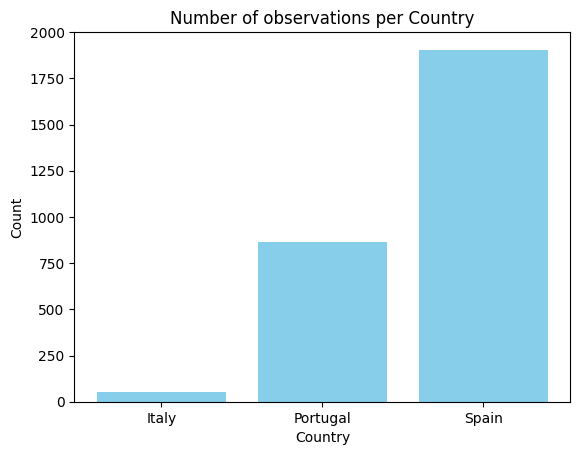

In [20]:
# Using matplotlib
# Plot a bar chart using the country counts, setting the bar color to sky blue
plt.bar(country_count.index, country_count['count'], color='skyblue')

# Set the label for the x-axis
plt.xlabel('Country')

# Set the label for the y-axis
plt.ylabel('Count')

# Set the title of the plot
plt.title('Number of observations per Country')

# Display the plot on the screen
plt.show()

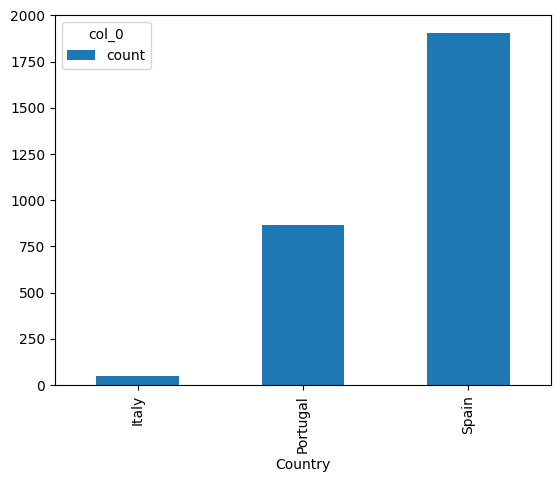

In [21]:
# using pandas 'plot' method
country_count.plot(kind='bar')
plt.show()

In [22]:
# getting help on the 'plot' method
help(country_count.plot)

Help on PlotAccessor in module pandas.plotting._core object:

class PlotAccessor(pandas.core.base.PandasObject)
 |  PlotAccessor(data: 'Series | DataFrame') -> 'None'
 |
 |  Make plots of Series or DataFrame.
 |
 |  Uses the backend specified by the
 |  option ``plotting.backend``. By default, matplotlib is used.
 |
 |  Parameters
 |  ----------
 |  data : Series or DataFrame
 |      The object for which the method is called.
 |  x : label or position, default None
 |      Only used if data is a DataFrame.
 |  y : label, position or list of label, positions, default None
 |      Allows plotting of one column versus another. Only used if data is a
 |      DataFrame.
 |  kind : str
 |      The kind of plot to produce:
 |
 |      - 'line' : line plot (default)
 |      - 'bar' : vertical bar plot
 |      - 'barh' : horizontal bar plot
 |      - 'hist' : histogram
 |      - 'box' : boxplot
 |      - 'kde' : Kernel Density Estimation plot
 |      - 'density' : same as 'kde'
 |      - 'area' 

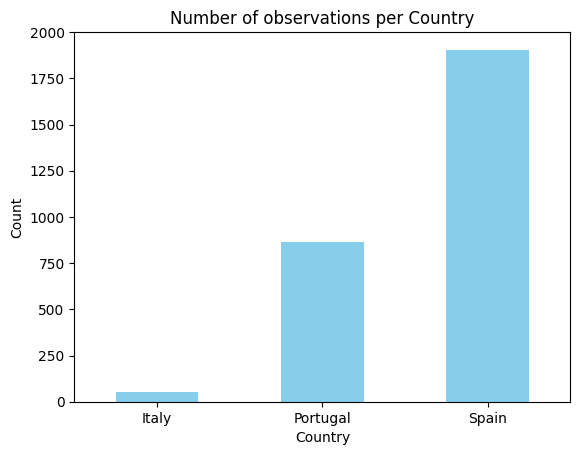

In [23]:
# Fine tuning pandas 'plot' method
country_count.plot(kind='bar',
                   legend=False,
                   color='skyblue',
                   title='Number of observations per Country',
                   xlabel='Country',
                   ylabel='Count',
                   rot=0) # rot=0 - rotation of x labels
plt.show()

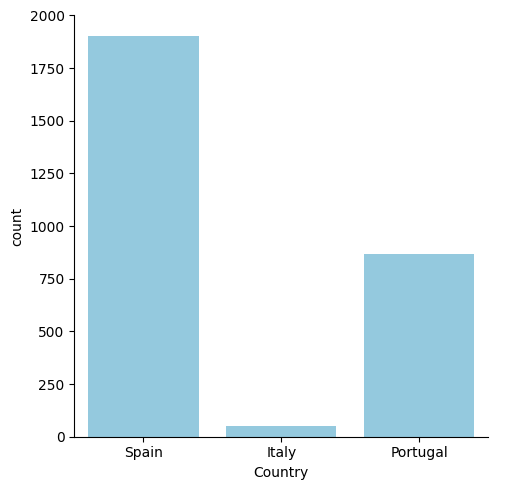

In [24]:
# Now using seaborn
sns.catplot(x="Country", data=df2, kind="count", color="skyblue")
plt.show()

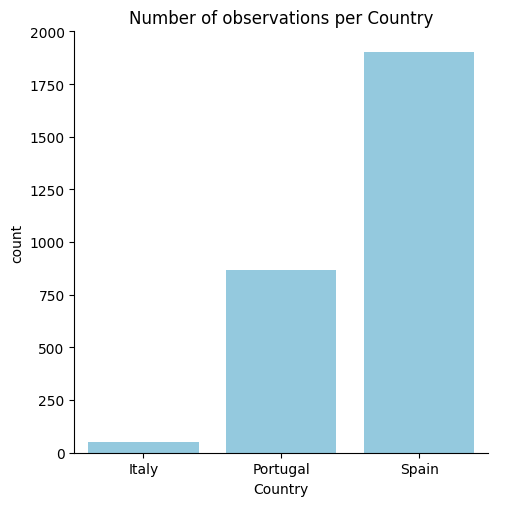

In [25]:
# Same thing but now changing the order and including a title:
sns.catplot(x="Country", data=df2, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain']).set(title='Number of observations per Country')
plt.show()

# Another way of including a title:
# ax = sns.catplot(x="Country", data=df, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain'])
# ax.set_titles('Number of observations per Country')
# plt.show()

Plotting the number of sites per catchment

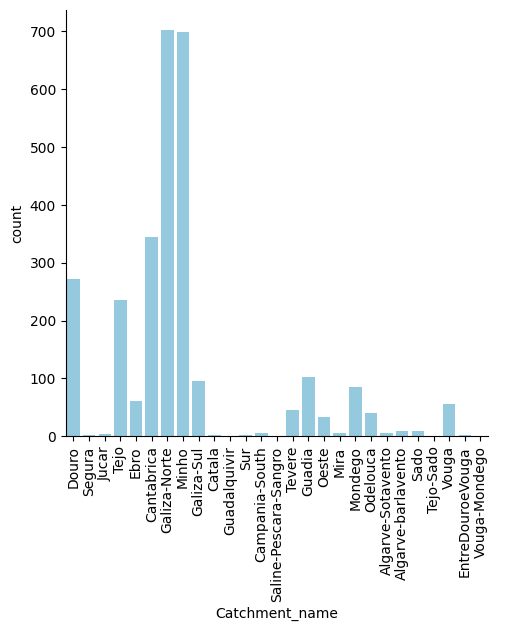

In [26]:
# using Seaborn
sns.catplot(x="Catchment_name", data=df2, kind="count", color="skyblue")
plt.xticks(rotation=90)
plt.show()

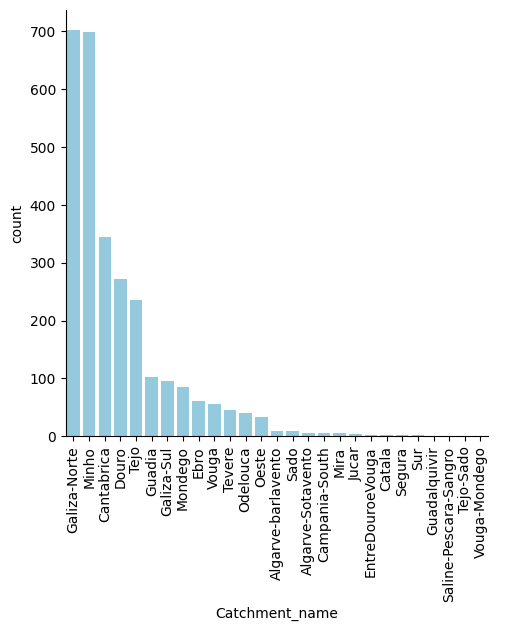

In [27]:
# Same thing but in a decreasing order:
order = df2["Catchment_name"].value_counts().index # the order of the categories is defined by the number of observations (decreasing order)

sns.catplot(x="Catchment_name", data=df2, kind="count", color="skyblue", order=order)
plt.xticks(rotation=90)
plt.show()

##### Pie charts

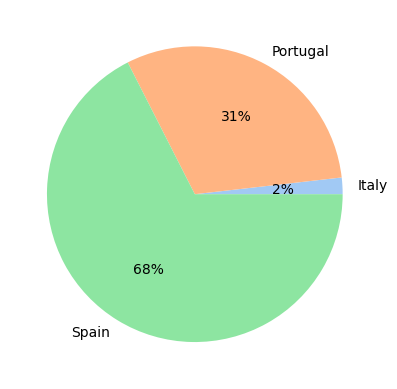

In [28]:
# pie chart
colors = sns.color_palette('pastel')
labels = list(country_count.index) # list of country names
plt.pie(list(country_count.iloc[:,0]), labels=labels, colors = colors, autopct = '%0.0f%%')
plt.show()

##### Treemaps

To plot treemaps you'll need to install `squarify`: run `pip install squarify` in the terminal.

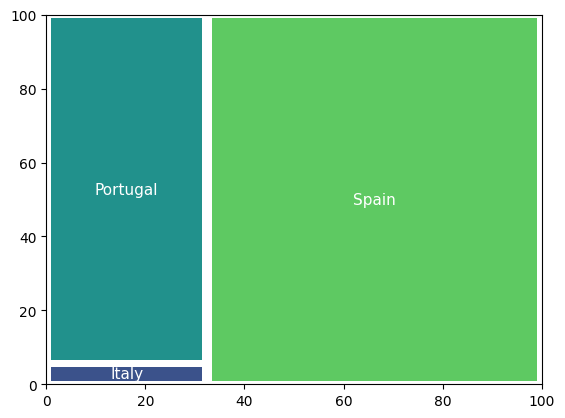

In [34]:
!pip install squarify
import squarify as sqrf

labels = list(country_count.index) # list of country names

sqrf.plot(sizes=list(country_count.iloc[:,0]), # select all rows from the 1st column of data
          label=labels, # names of countries
          color=sns.color_palette('viridis',n_colors=len(labels)), # color palette
          text_kwargs={'fontsize': 11, 'color':"white"}, # label format
          pad=0.25) # define space between areas
plt.show()

### Plotting quantitative data

#### Strip plots
check here: https://seaborn.pydata.org/generated/seaborn.stripplot.html

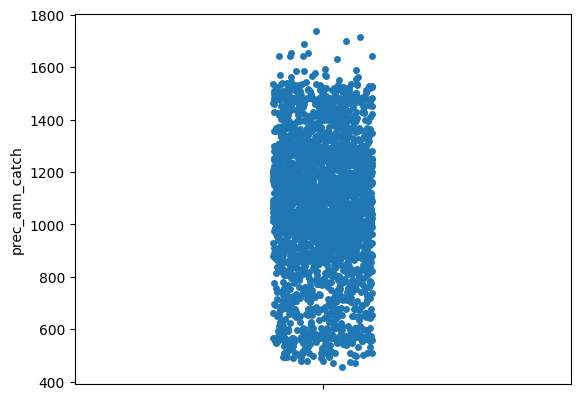

In [35]:
# plot the mean annual total precipitation in the upstream catchment of each site
sns.stripplot(df2['prec_ann_catch'])
plt.show()


#### Histograms
check here: https://seaborn.pydata.org/generated/seaborn.histplot.html

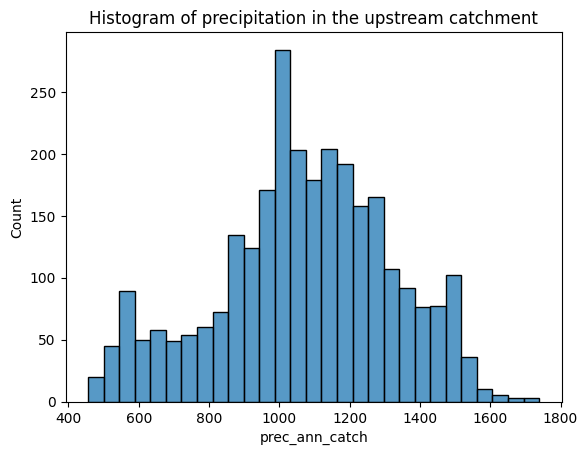

In [36]:
# histogram of the mean annual total precipitation in the upstream catchment of each site
sns.histplot(df2['prec_ann_catch'], kde = False).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

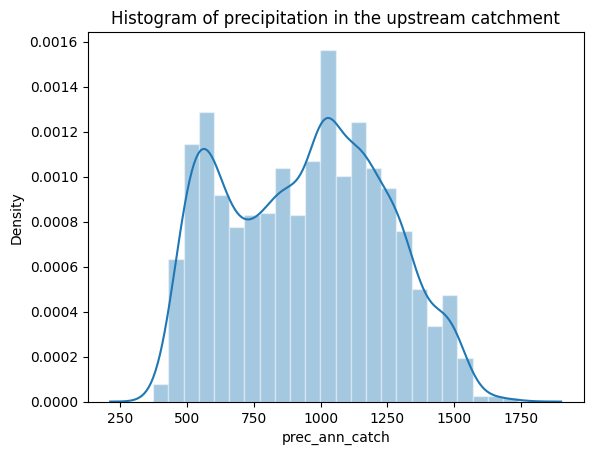

In [37]:
# More variations
sns.histplot(
    df["prec_ann_catch"],
    kde=True,
    stat="density", # plot proportions instead of frequencies
    kde_kws=dict(cut=3),
    alpha=.4, # transparency
    edgecolor=(1, 1, 1, 0.4), # bar contour lines (r, g, b, alpha)
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

### Bar plots

Check here: https://seaborn.pydata.org/generated/seaborn.barplot.html

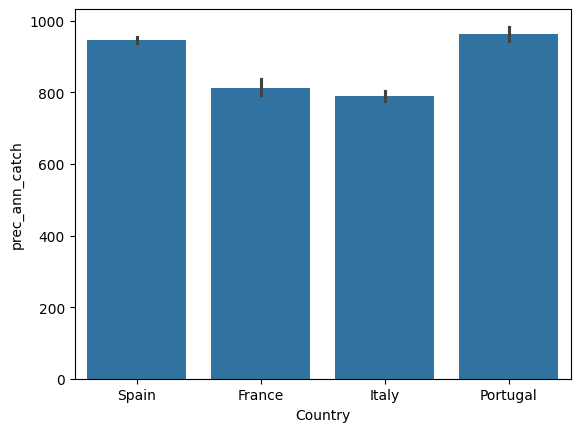

In [38]:
# bar plot of Total Annual Precipitation by country
sns.barplot(x="Country", y="prec_ann_catch", data=df)
plt.show()

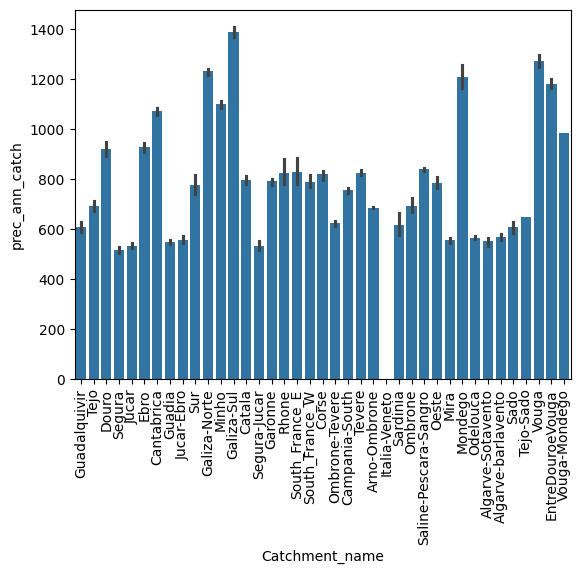

In [39]:
# bar plot of Total Annual Precipitation by catchment
sns.barplot(data=df, x="Catchment_name", y="prec_ann_catch")
plt.xticks(rotation=90)
plt.show()

### Boxplots

Check here: https://seaborn.pydata.org/generated/seaborn.boxplot.html

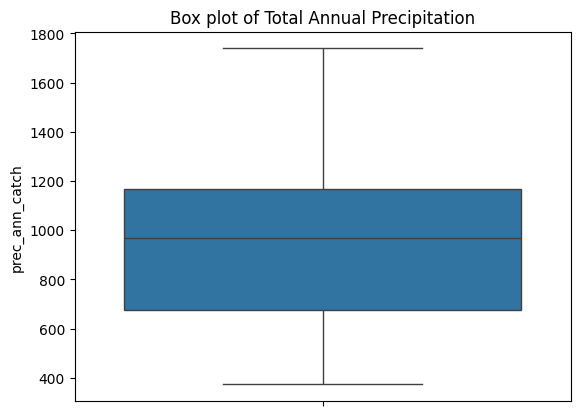

In [40]:
# Box plot of Total Annual Precipitation
sns.boxplot(df["prec_ann_catch"]).set_title("Box plot of Total Annual Precipitation")
plt.show()

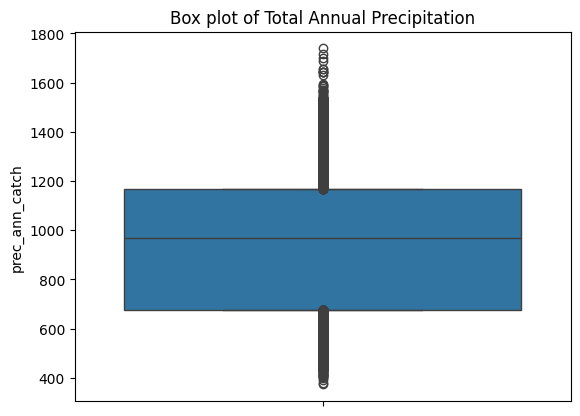

In [41]:
# no whiskers (data points outside the box instead)
sns.boxplot(df["prec_ann_catch"], whis=0).set_title("Box plot of Total Annual Precipitation")
plt.show()

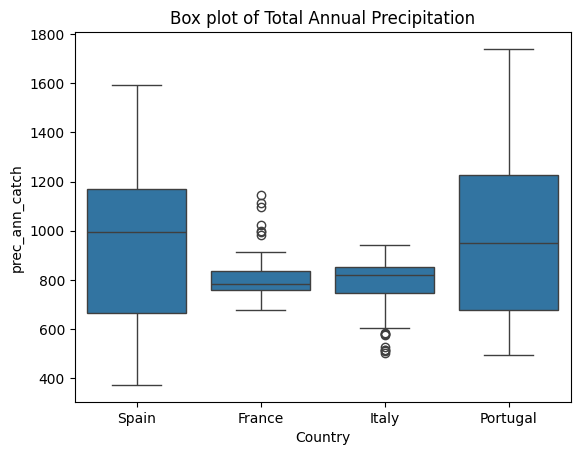

In [42]:
# Box plot of Total Annual Precipitation by country
sns.boxplot(x="Country", y="prec_ann_catch", data=df).set_title("Box plot of Total Annual Precipitation")
plt.show()

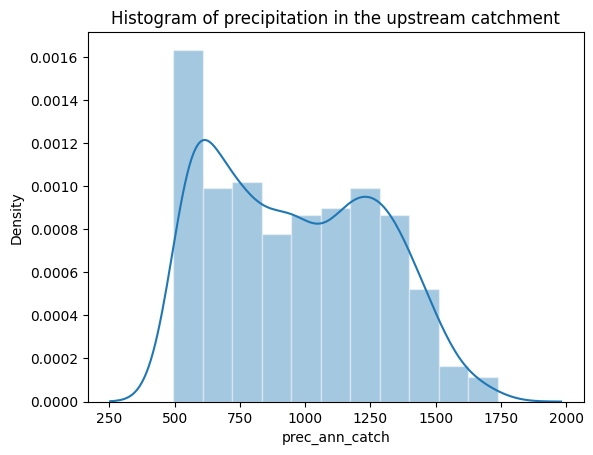

In [43]:
# same thing but only for Portugal
df_port = df[df['Country']=='Portugal']

sns.histplot(
    df_port["prec_ann_catch"],
    kde=True,
    stat="density",
    kde_kws=dict(cut=3),
    alpha=.4,
    edgecolor=(1, 1, 1, 0.4),
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()


### Violin plots

Check here: https://seaborn.pydata.org/generated/seaborn.violinplot.html

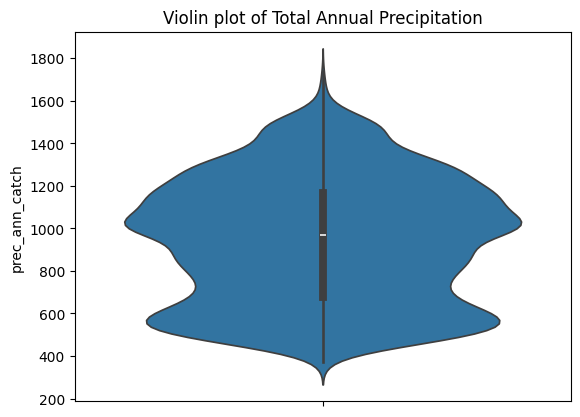

In [44]:
# violin plot of Total Annual Precipitation by country
sns.violinplot(data=df, y="prec_ann_catch").set_title("Violin plot of Total Annual Precipitation")
plt.show()

### Raincloud plots

Raincloud plots combine violin plots, boxplots and strip plots into a single chart. To plot raincloud plots it is helpful to use the `ptitprince` library. You may need to install `ptitprince`by running `pip install ptitprince` in the terminal.

In [46]:
!pip install ptitprince
import ptitprince as pt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16216 sha256=105e89d267ea4866ff12c3c7e3b95bca15e958ab1ca298b61b4ed06251882ae4
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


In [47]:
help(pt.RainCloud)

Help on function RainCloud in module ptitprince.PtitPrince:

RainCloud(x: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, y: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, hue: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, data: Optional[pandas.core.frame.DataFrame] = None, order: Optional[list[str]] = None, hue_order: Optional[list[str]] = None, orient: str = 'v', width_viol: float = 0.7, width_box: float = 0.15, palette: Union[str, list, dict, NoneType] = None, bw: Union[str, float] = 0.2, linewidth: float = 1, cut: float = 0.0, scale: str = 'area', jitter: bool = True, move: float = 0.0, offset: Optional[float] = None, point_size: float = 3, ax: Optional[matplotlib.axes._axes.Axes] = None, pointplot: bool = False, alpha: Optional[float] = None, dodge: bool = False, linecolor: str = 'red', **kwargs: Any) -> matplotlib.axes._axes.Axes
    Draw a Raincloud plot of measure `y` of different categories `x`.

    He

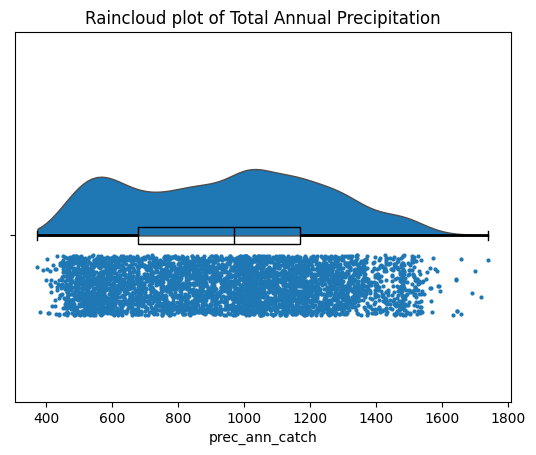

In [48]:
# Raincloud plot of Total Annual Precipitation

pt.RainCloud(y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=0.4, # width of the half violin (cloud)
             width_box=0.05, # width of the box
             orient='h', # orientation
             move=0.15, # position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

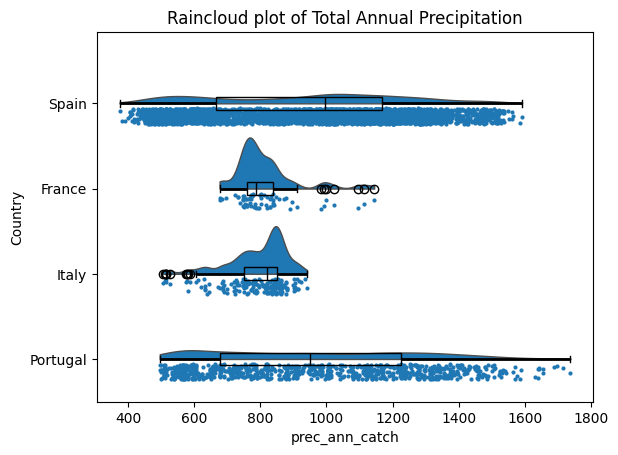

In [49]:
# Raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.15, # wdth of the box
             orient='h', # orientation
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

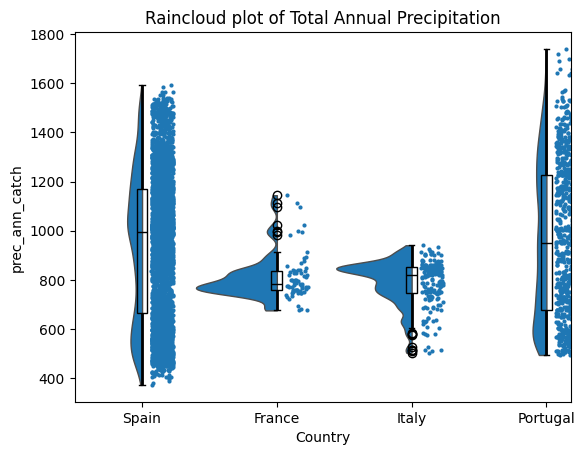

In [50]:
# Vertical raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.08, # wdth of the box
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.08) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

### Part 1: Plotting `temp_ann` for the four catchments with the highest number of fish sampling sites

In [51]:
# Identify the four catchments with the highest number of fish sampling sites
top_4_catchments = catchment_count.sort_values(by='count', ascending=False).head(4).index.tolist()
print(f"Top 4 catchments: {top_4_catchments}")

Top 4 catchments: ['Galiza-Norte', 'Minho', 'Cantabrica', 'Douro']


In [52]:
# Filter the dataframe for these top 4 catchments
df_top4_catchments = df2[df2['Catchment_name'].isin(top_4_catchments)]

In [53]:
# Set a consistent color palette for plots
palette = sns.color_palette('viridis', n_colors=len(top_4_catchments))

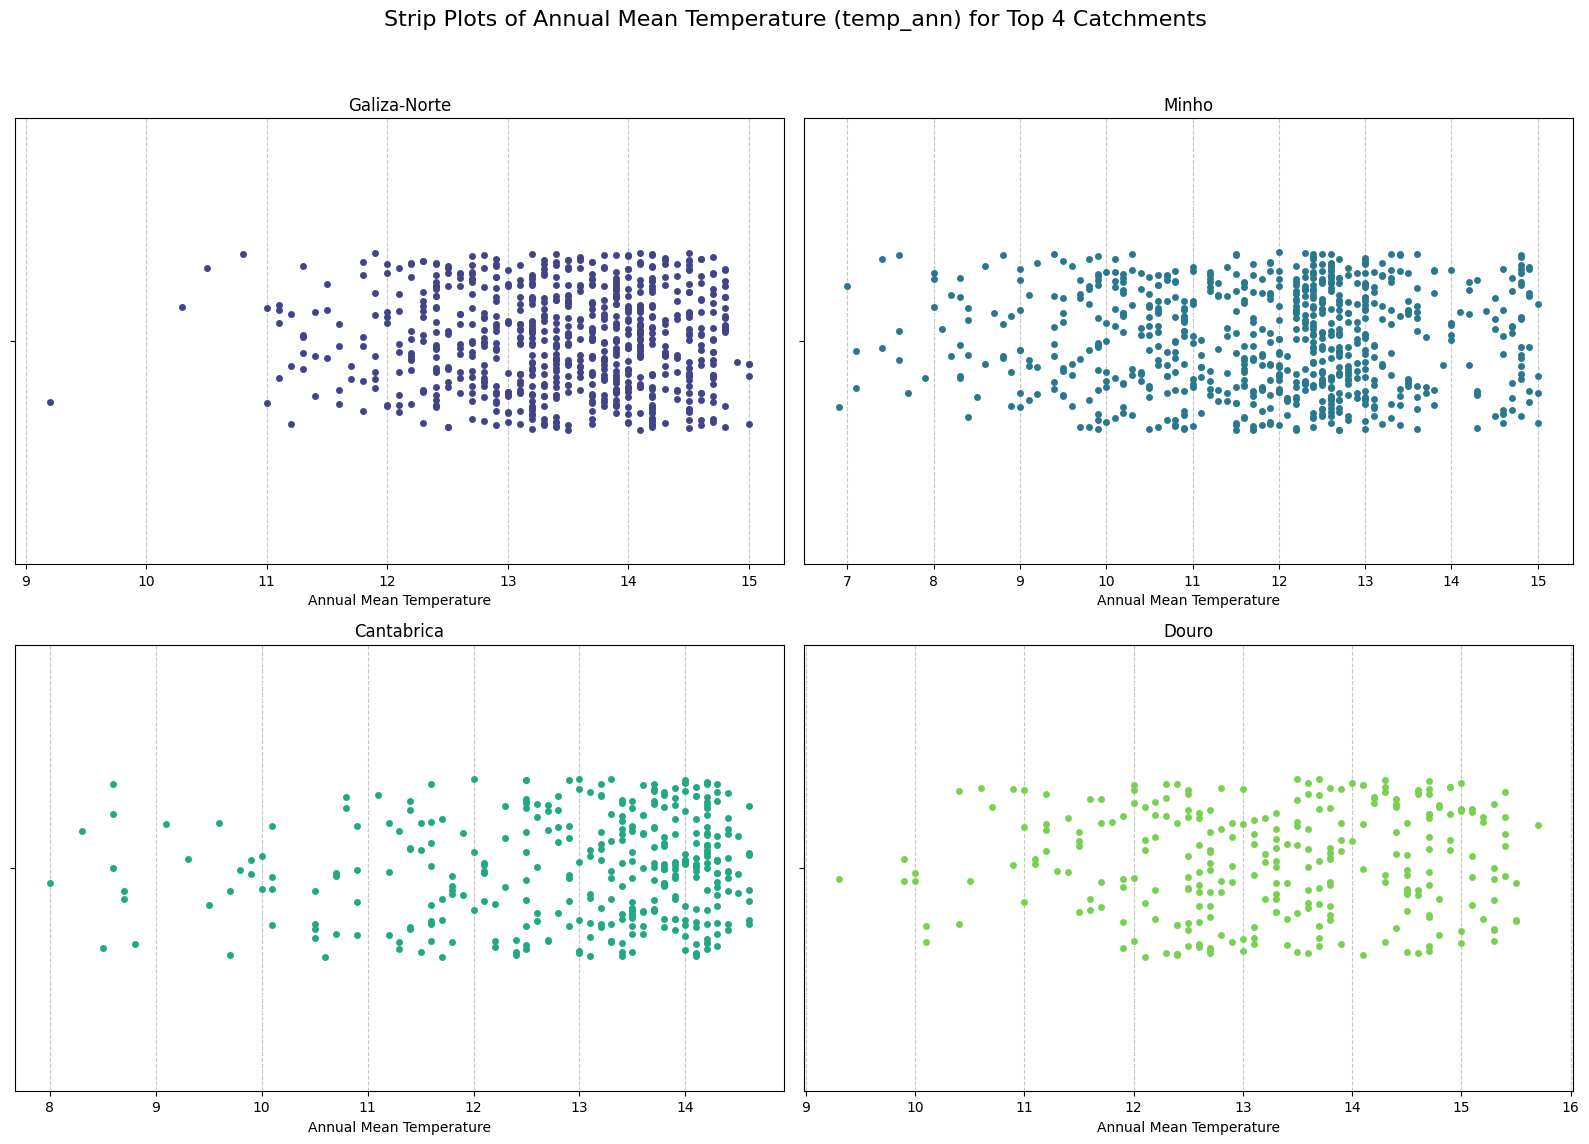

In [54]:
# --- Strip Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

fig.suptitle('Strip Plots of Annual Mean Temperature (temp_ann) for Top 4 Catchments', fontsize=16)

for i, catchment in enumerate(top_4_catchments):
    sns.stripplot(x=df_top4_catchments[df_top4_catchments['Catchment_name'] == catchment]['temp_ann'],
                  ax=axes[i], color=palette[i], jitter=0.2)
    axes[i].set_title(f'{catchment}')
    axes[i].set_xlabel('Annual Mean Temperature')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

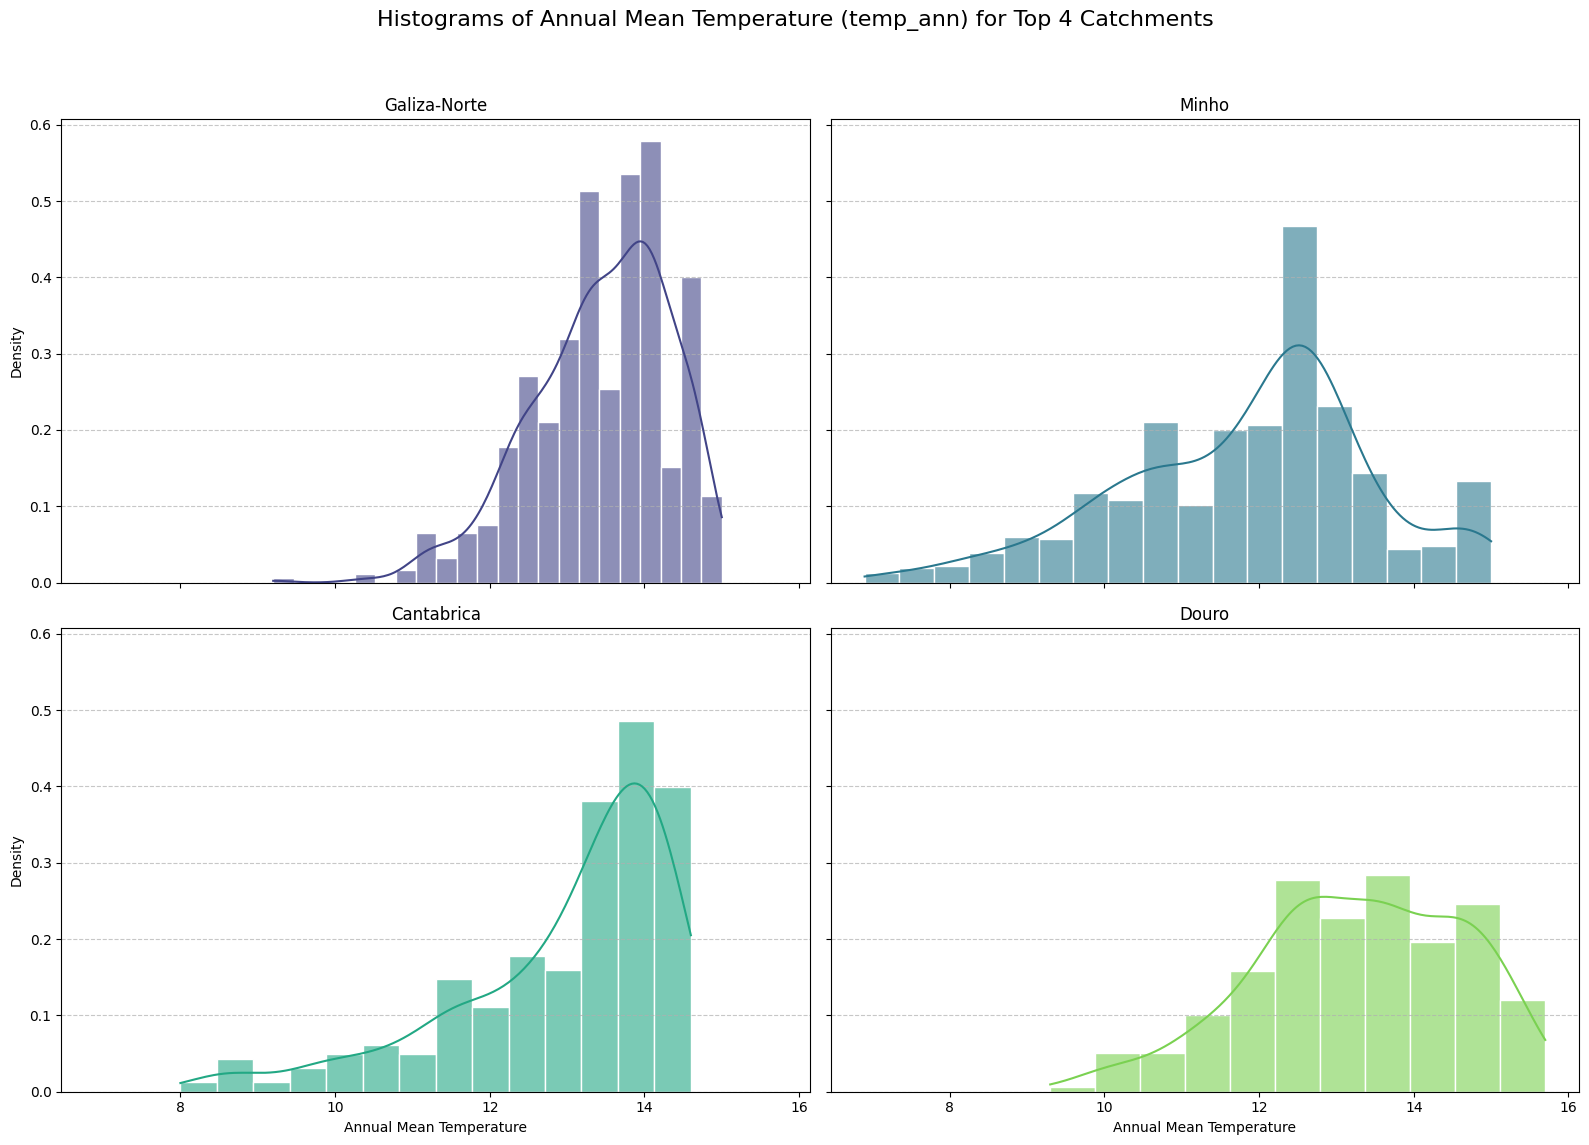

In [55]:
# --- Histograms ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True, sharex=True)
axes = axes.flatten()

fig.suptitle('Histograms of Annual Mean Temperature (temp_ann) for Top 4 Catchments', fontsize=16)

for i, catchment in enumerate(top_4_catchments):
    sns.histplot(df_top4_catchments[df_top4_catchments['Catchment_name'] == catchment]['temp_ann'],
                 kde=True, ax=axes[i], color=palette[i], stat='density', alpha=0.6, edgecolor='white')
    axes[i].set_title(f'{catchment}')
    axes[i].set_xlabel('Annual Mean Temperature')
    axes[i].set_ylabel('Density')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

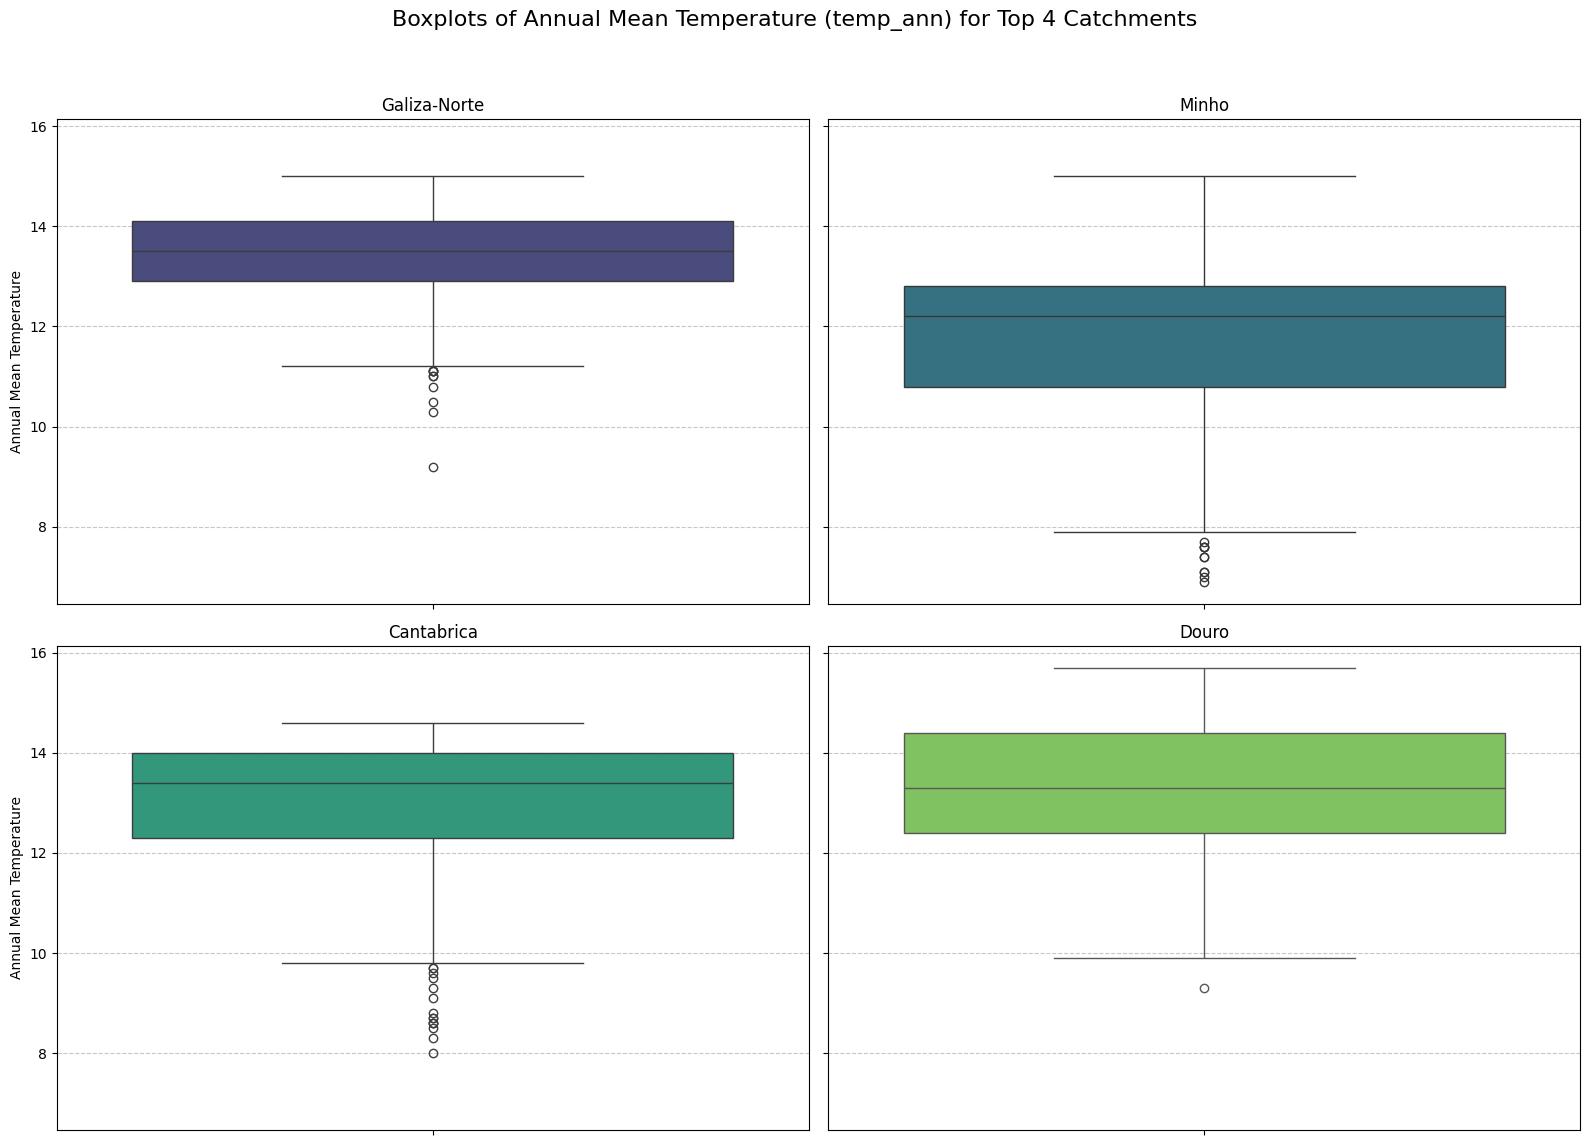

In [56]:
# --- Boxplots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True, sharex=True)
axes = axes.flatten()

fig.suptitle('Boxplots of Annual Mean Temperature (temp_ann) for Top 4 Catchments', fontsize=16)

for i, catchment in enumerate(top_4_catchments):
    sns.boxplot(y=df_top4_catchments[df_top4_catchments['Catchment_name'] == catchment]['temp_ann'],
                ax=axes[i], color=palette[i], orient='v', whis=1.5)
    axes[i].set_title(f'{catchment}')
    axes[i].set_ylabel('Annual Mean Temperature')
    axes[i].set_xlabel('') # Remove x-axis label for vertical boxplots
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Evaluation of Plot Types:

**Strip Plots:**
*   **Pros:** Shows every individual data point, which is useful for small datasets or to visualize the density of points directly. Helps identify outliers easily. Good for showing the exact distribution without aggregation.
*   **Cons:** Can become very cluttered and difficult to interpret with large datasets, as points overlap significantly. Not ideal for summarizing large quantities of data quickly.

**Histograms:**
*   **Pros:** Excellent for visualizing the distribution shape, central tendency, and spread of a single numerical variable. Easy to understand and identify patterns like skewness or multimodality. Effective for large datasets.
*   **Cons:** The appearance can be sensitive to the number of bins chosen, which can sometimes obscure details. Doesn't show individual data points or exact values, only frequency within bins.

**Boxplots:**
*   **Pros:** Provides a clear summary of the five-number summary (minimum, first quartile, median, third quartile, maximum) and outliers. Very effective for comparing distributions across different groups or categories. Good for showing spread and skewness.
*   **Cons:** Hides the actual distribution shape within the quartiles (e.g., cannot distinguish between a unimodal or bimodal distribution within the box). Does not show the density of data points.

### Part 2: How the mean value of `temp_ann` varies with the size of random samplings of sites

In [57]:
# Sample sizes to test
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]
num_samples = 1000

# Store the means of each sample
sample_means = {size: [] for size in sample_sizes}

# Perform random sampling
for size in sample_sizes:
    for _ in range(num_samples):
        # Sample with replacement
        sample = df2['temp_ann'].sample(n=size, replace=True)
        sample_means[size].append(sample.mean())

print("Random sampling completed. Sample means collected for various sizes.")

Random sampling completed. Sample means collected for various sizes.


In [58]:
# Create a DataFrame for easier plotting
df_sample_means = pd.DataFrame([(size, mean) for size, means_list in sample_means.items() for mean in means_list],
                               columns=['Sample_Size', 'Sample_Mean_Temp_Ann'])
display(df_sample_means.head())

,Sample_Size,Sample_Mean_Temp_Ann
0,10,14.03
1,10,13.13
2,10,13.08
3,10,13.44
4,10,13.09


In [60]:
import numpy as np

# Population mean of temp_ann from df2 (cleaned data)
population_mean_temp_ann = df2['temp_ann'].mean()
print(f"Population Mean of temp_ann: {population_mean_temp_ann:.2f}")

Population Mean of temp_ann: 13.43


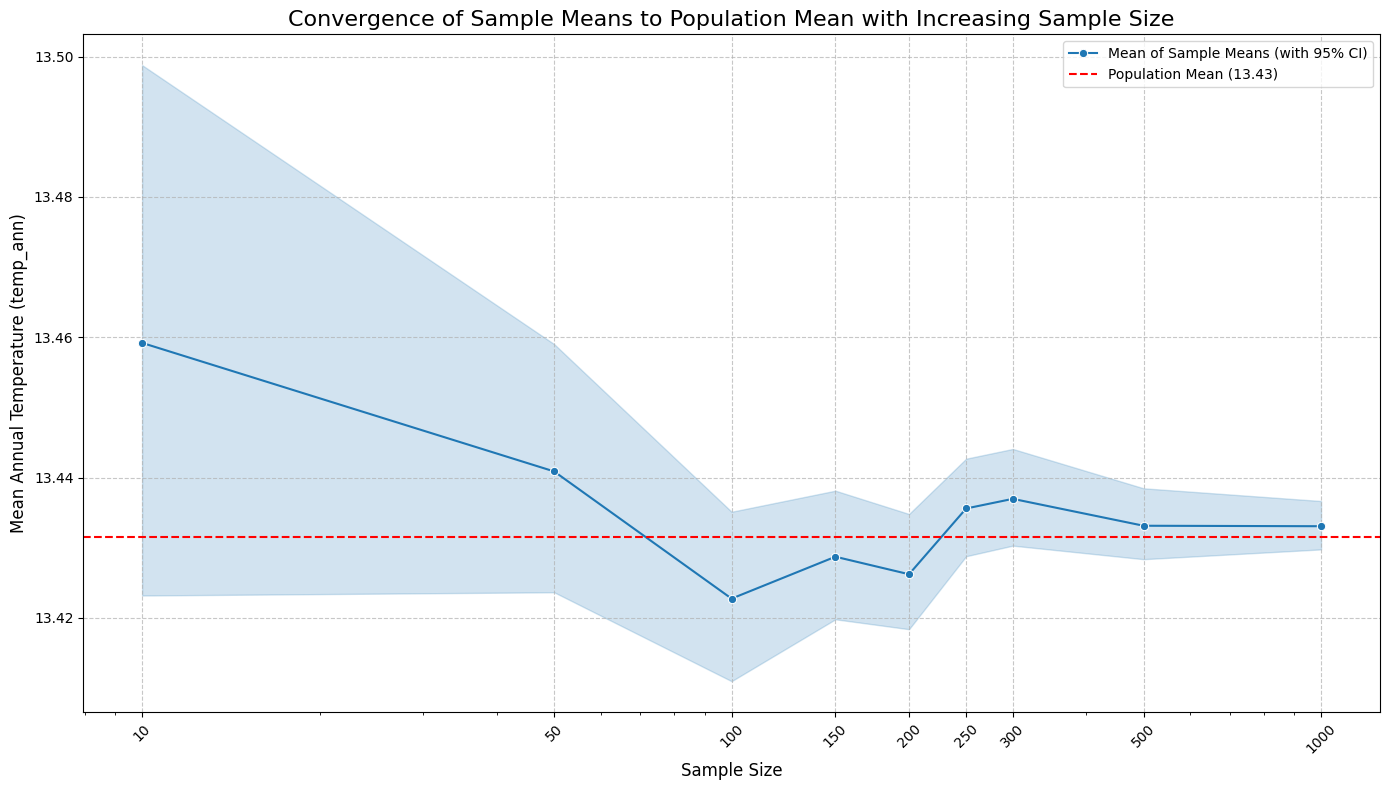

In [61]:
# --- Visualization of Convergence ---
plt.figure(figsize=(14, 8))

sns.lineplot(x='Sample_Size', y='Sample_Mean_Temp_Ann', data=df_sample_means,
             estimator='mean', errorbar=('ci', 95), marker='o', label='Mean of Sample Means (with 95% CI)')

# Plot the population mean for reference
plt.axhline(y=population_mean_temp_ann, color='r', linestyle='--', label=f'Population Mean ({population_mean_temp_ann:.2f})')

plt.title('Convergence of Sample Means to Population Mean with Increasing Sample Size', fontsize=16)
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel('Mean Annual Temperature (temp_ann)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xscale('log') # Use log scale for x-axis to better visualize spread at smaller sizes
plt.xticks(sample_sizes, labels=[str(s) for s in sample_sizes]) # Set explicit x-ticks
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

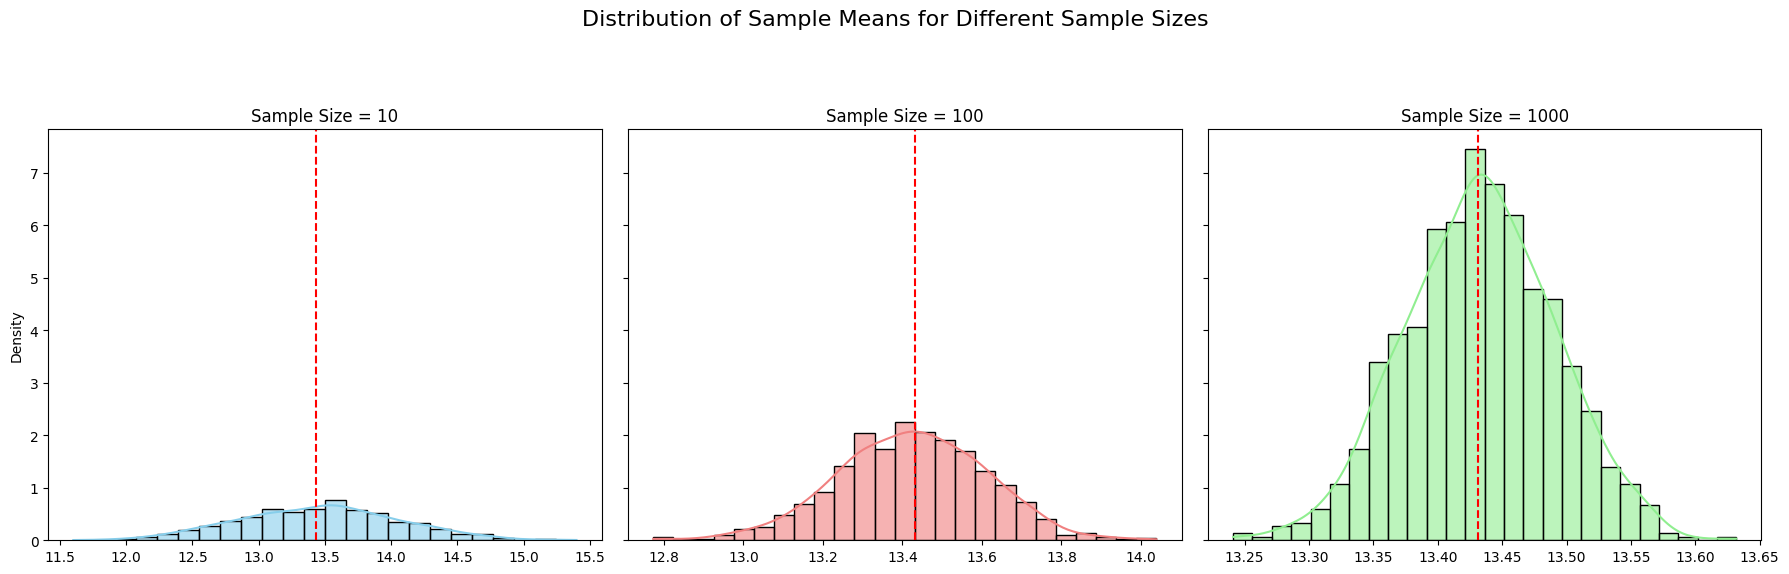

In [62]:
# --- Visualization of Distribution of Sample Means ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Distribution of Sample Means for Different Sample Sizes', fontsize=16)

sns.histplot(sample_means[10], kde=True, ax=axes[0], color='skyblue', stat='density', alpha=0.6)
axes[0].set_title('Sample Size = 10')
axes[0].axvline(population_mean_temp_ann, color='r', linestyle='--')

sns.histplot(sample_means[100], kde=True, ax=axes[1], color='lightcoral', stat='density', alpha=0.6)
axes[1].set_title('Sample Size = 100')
axes[1].axvline(population_mean_temp_ann, color='r', linestyle='--')

sns.histplot(sample_means[1000], kde=True, ax=axes[2], color='lightgreen', stat='density', alpha=0.6)
axes[2].set_title('Sample Size = 1000')
axes[2].axvline(population_mean_temp_ann, color='r', linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

### Interpretation of Sample Mean Variation:

The line plot illustrates the Central Limit Theorem in action. As the sample size increases, the mean of the sample means (represented by the blue line) converges towards the true population mean (the red dashed line). The shaded area around the blue line represents the 95% confidence interval, which quantifies the uncertainty in the estimate of the mean. You can observe that this confidence interval narrows significantly as the sample size grows.

The histograms of sample means for different sample sizes further demonstrate this:

*   **Smaller Sample Sizes (e.g., 10):** The distribution of sample means is wider, indicating more variability and less precision in estimating the population mean from a single small sample.
*   **Larger Sample Sizes (e.g., 100, 1000):** The distribution of sample means becomes narrower and more concentrated around the population mean, closely resembling a normal distribution. This indicates that with larger sample sizes, individual sample means are more likely to be close to the true population mean, and thus provide a more reliable estimate.